In [1]:
import pandas as pd

# Load kinase interactions data (CSV file)
kinase_df = pd.read_csv(r"C:\Users\Tim\kinase_interactions.csv")

# Display first few rows of kinase interactions data
print("Kinase Interactions Data:")
print(kinase_df.head())

# Load the Excel file for top 20 structures
top_20_df = pd.read_excel(r"C:\Users\Tim\OneDrive\Documents\Copy of TOP_20_FOR_STRUCTURE(1).xlsx")

# Display first few rows of top 20 structures data
print("\nTop 20 Structures Data:")
print(top_20_df.head())

Kinase Interactions Data:
  Kinase        Source Protein        Target Protein  Interaction Score
0  AURKA  9606.ENSP00000216911  9606.ENSP00000288207              0.988
1  AURKA  9606.ENSP00000216911  9606.ENSP00000368759              0.990
2  AURKA  9606.ENSP00000216911  9606.ENSP00000301633              0.993
3  AURKA  9606.ENSP00000216911  9606.ENSP00000378295              0.994
4  AURKA  9606.ENSP00000216911  9606.ENSP00000361540              0.995

Top 20 Structures Data:
   KINASE                                              FASTA
0   AURKA  MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...
1    PAK1  MSNNGLDIQDKPPAPPMRNTSTMIGAGSKDAGTLNHGSKPLPPNPE...
2  PDGFRB  MRLPGAMPALALKGELLLLSLLLLLEPQISQGLVVTPPGPELVLNV...
3     LYN  MGCIKSKGKDSLSDDGVDLKTQPVRNTERTIYVRDPTSNKQQRPVP...
4    EGFR  MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...


In [3]:
# Rename columns to ensure they match for the merge
kinase_df.rename(columns={'Kinase': 'KINASE'}, inplace=True)

# Now, perform the merge
merged_df = pd.merge(kinase_df, top_20_df, on='KINASE', how='inner')

# Display the merged dataframe
print(merged_df.head())

  KINASE        Source Protein        Target Protein  Interaction Score  \
0  AURKA  9606.ENSP00000216911  9606.ENSP00000288207              0.988   
1  AURKA  9606.ENSP00000216911  9606.ENSP00000368759              0.990   
2  AURKA  9606.ENSP00000216911  9606.ENSP00000301633              0.993   
3  AURKA  9606.ENSP00000216911  9606.ENSP00000378295              0.994   
4  AURKA  9606.ENSP00000216911  9606.ENSP00000361540              0.995   

                                               FASTA  
0  MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...  
1  MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...  
2  MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...  
3  MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...  
4  MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...  


In [4]:
# Preprocessing - Check for missing values and clean data
kinase_df.isnull().sum()  # Check for missing values in Kinase interaction data
top_20_df.isnull().sum()  # Check for missing values in FASTA sequences

# Drop rows with missing kinase data
kinase_df = kinase_df.dropna(subset=['KINASE', 'Source Protein', 'Target Protein', 'Interaction Score'])
top_20_df = top_20_df.dropna(subset=['KINASE', 'FASTA'])

# Example of sequence normalization (if needed)
# For FASTA sequences, we can normalize by length (or use any other relevant transformation)
top_20_df['FASTA_length'] = top_20_df['FASTA'].apply(len)

In [5]:
top_20_df

,KINASE,FASTA,FASTA_length
0,AURKA,MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...,403
1,PAK1,MSNNGLDIQDKPPAPPMRNTSTMIGAGSKDAGTLNHGSKPLPPNPE...,545
2,PDGFRB,MRLPGAMPALALKGELLLLSLLLLLEPQISQGLVVTPPGPELVLNV...,1106
3,LYN,MGCIKSKGKDSLSDDGVDLKTQPVRNTERTIYVRDPTSNKQQRPVP...,512
4,EGFR,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,1210
5,AKT1,MSDVAIVKEGWLHKRGEYIKTWRPRYFLLKNDGTFIGYKERPQDVD...,480
6,TGFBR1,MEAAVAAPRPRLLLLVLAAAAAAAAALLPGATALQCFCHLCTKDNF...,503
7,DYRK1,MHTGGETSACKPSSVRLAPSFSFHAAGLQMAGQMPHSHQYSDRRQP...,763
8,MTOR,MLGTGPAAATTAATTSSNVSVLQQFASGLKSRNEETRAKAAKELQH...,2549
9,CDK1,MEDYTKIEKIGEGTYGVVYKGRHKTTGQVVAMKKIRLESEEEGVPS...,297


In [7]:
from skimage.feature import greycomatrix, greycoprops
import numpy as np

# Function to encode amino acid sequence to numeric representation
def encode_sequence(fasta):
    aa_to_int = {'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4, 'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9,
                 'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14, 'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19}
    return np.array([aa_to_int.get(aa, -1) for aa in fasta])  # -1 for unknown amino acids

# Function to calculate GLCM features
def calculate_glcm_features(fasta):
    # Encode sequence into integers
    encoded = encode_sequence(fasta)
    
    # Reshape to 2D (needed for GLCM calculation)
    encoded_2d = np.reshape(encoded, (1, len(encoded)))

    # Specify the number of levels based on the possible range of encoded amino acids (0-19)
    levels = 20  # Since we have 20 amino acids

    # Calculate GLCM and extract properties like contrast, correlation, etc.
    glcm = greycomatrix(encoded_2d, distances=[1], angles=[0], symmetric=True, normed=True, levels=levels)
    
    # Extract GLCM properties
    contrast = greycoprops(glcm, 'contrast')[0, 0]
    correlation = greycoprops(glcm, 'correlation')[0, 0]
    homogeneity = greycoprops(glcm, 'homogeneity')[0, 0]
    energy = greycoprops(glcm, 'energy')[0, 0]
    
    return contrast, correlation, homogeneity, energy

# Apply feature extraction to each FASTA sequence
top_20_df[['contrast', 'correlation', 'homogeneity', 'energy']] = top_20_df['FASTA'].apply(calculate_glcm_features).apply(pd.Series)

# Display the extracted features
print(top_20_df[['KINASE', 'contrast', 'correlation', 'homogeneity', 'energy']].head())

   KINASE   contrast  correlation  homogeneity    energy
0   AURKA  56.460199    -0.012756     0.141848  0.072865
1    PAK1  55.805147     0.037259     0.175468  0.071123
2  PDGFRB  62.198190    -0.005728     0.151213  0.067231
3     LYN  60.571429     0.026390     0.149799  0.066262
4    EGFR  62.034739    -0.018666     0.149673  0.060722


In [9]:
# Merge the two dataframes based on 'KINASE' column
merged_df = pd.merge(kinase_df, top_20_df[['KINASE', 'contrast', 'correlation', 'homogeneity', 'energy']], 
                     on='KINASE', how='inner')

# Display the merged dataframe with kinase interactions and extracted GLCM features
print("\nMerged DataFrame with Kinase Interactions and GLCM Features:")
print(merged_df.head())

# Now, you can further prepare the data for model training
# For example, let's assume you want to predict the Interaction Score using the GLCM features
X = merged_df[['contrast', 'correlation', 'homogeneity', 'energy']]  # Features
y = merged_df['Interaction Score']  # Target variable


Merged DataFrame with Kinase Interactions and GLCM Features:
  KINASE        Source Protein        Target Protein  Interaction Score  \
0  AURKA  9606.ENSP00000216911  9606.ENSP00000288207              0.988   
1  AURKA  9606.ENSP00000216911  9606.ENSP00000368759              0.990   
2  AURKA  9606.ENSP00000216911  9606.ENSP00000301633              0.993   
3  AURKA  9606.ENSP00000216911  9606.ENSP00000378295              0.994   
4  AURKA  9606.ENSP00000216911  9606.ENSP00000361540              0.995   

    contrast  correlation  homogeneity    energy  
0  56.460199    -0.012756     0.141848  0.072865  
1  56.460199    -0.012756     0.141848  0.072865  
2  56.460199    -0.012756     0.141848  0.072865  
3  56.460199    -0.012756     0.141848  0.072865  
4  56.460199    -0.012756     0.141848  0.072865  


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the evaluation metrics
print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

# Display the predicted vs actual values for a sample of test data
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredicted vs Actual (Sample):")
print(comparison_df.head())


Model Evaluation:
Mean Squared Error (MSE): 0.006475293293761508
R-squared (R2): -0.09562822943838434

Predicted vs Actual (Sample):
     Actual  Predicted
394   0.998   0.962194
66    0.703   0.928865
495   0.999   0.948573
67    0.973   0.928865
854   0.975   0.935367


Epoch 1/100
22/22 [==============================] - 1s 15ms/step - loss: 0.6915 - val_loss: 0.3059
Epoch 2/100
22/22 [==============================] - 0s 3ms/step - loss: 0.1307 - val_loss: 0.0485
Epoch 3/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0299 - val_loss: 0.0183
Epoch 4/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0156 - val_loss: 0.0152
Epoch 5/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0125 - val_loss: 0.0129
Epoch 6/100
22/22 [==============================] - 0s 2ms/step - loss: 0.0108 - val_loss: 0.0114
Epoch 7/100
22/22 [==============================] - 0s 2ms/step - loss: 0.0097 - val_loss: 0.0103
Epoch 8/100
22/22 [==============================] - 0s 2ms/step - loss: 0.0089 - val_loss: 0.0095
Epoch 9/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0082 - val_loss: 0.0094
Epoch 10/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0078 - val_loss: 0.0090
Epoch 11

22/22 [==============================] - 0s 3ms/step - loss: 0.0056 - val_loss: 0.0063
Epoch 84/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0055 - val_loss: 0.0066
Epoch 85/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0054 - val_loss: 0.0062
Epoch 86/100
22/22 [==============================] - 0s 2ms/step - loss: 0.0056 - val_loss: 0.0066
Epoch 87/100
22/22 [==============================] - 0s 2ms/step - loss: 0.0058 - val_loss: 0.0069
Epoch 88/100
22/22 [==============================] - 0s 2ms/step - loss: 0.0056 - val_loss: 0.0068
Epoch 89/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0058 - val_loss: 0.0066
Epoch 90/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0054 - val_loss: 0.0066
Epoch 91/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0055 - val_loss: 0.0072
Epoch 92/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0059 - val_loss: 0.0069
Epoch 93/100


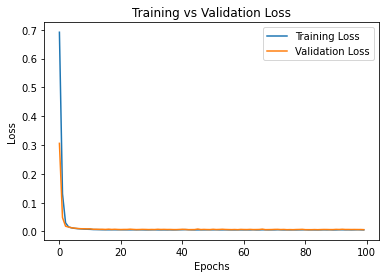

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define the deep learning model
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),  # Input layer + 1st hidden layer
    Dense(64, activation='relu'),  # 2nd hidden layer
    Dense(32, activation='relu'),  # 3rd hidden layer
    Dense(1)  # Output layer (predicting a continuous value)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Evaluate the model
loss = model.evaluate(X_test, y_test)

# Predict on the test set
y_pred_dl = model.predict(X_test)

# Evaluate the model performance
mse_dl = mean_squared_error(y_test, y_pred_dl)
r2_dl = r2_score(y_test, y_pred_dl)

# Display evaluation results
print("\nDeep Learning Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_dl}")
print(f"R-squared (R2): {r2_dl}")

# Optionally, plot the loss over epochs to visualize training progress
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

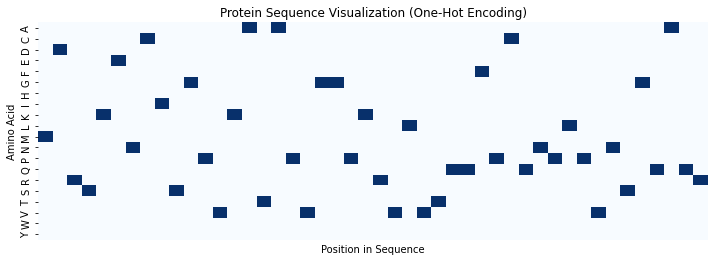

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns

# Amino acid to index mapping (using standard 20 amino acids)
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_index = {aa: i for i, aa in enumerate(amino_acids)}

# Example FASTA sequence (you can use your actual sequences here)
fasta_example = "MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR"  # Just an example

# Function to convert a FASTA sequence into one-hot encoding
def one_hot_encode(sequence):
    # Create an empty matrix for one-hot encoding
    encoded = np.zeros((len(sequence), len(amino_acids)), dtype=int)
    
    # Fill the matrix with one-hot encoding
    for i, aa in enumerate(sequence):
        if aa in aa_to_index:
            encoded[i, aa_to_index[aa]] = 1
    
    return encoded

# Convert FASTA sequence to one-hot encoded matrix
encoded_sequence = one_hot_encode(fasta_example)

# Visualize the encoded sequence as a heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(encoded_sequence.T, cmap='Blues', cbar=False, xticklabels=False, yticklabels=amino_acids)
plt.title('Protein Sequence Visualization (One-Hot Encoding)')
plt.xlabel('Position in Sequence')
plt.ylabel('Amino Acid')
plt.show()

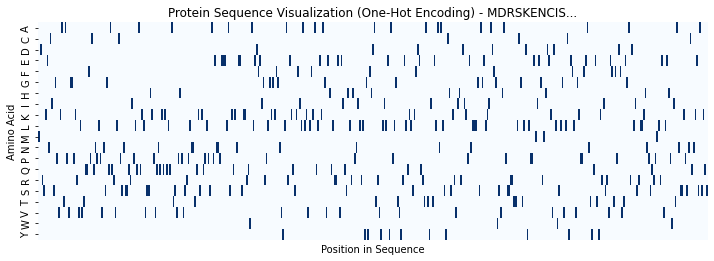

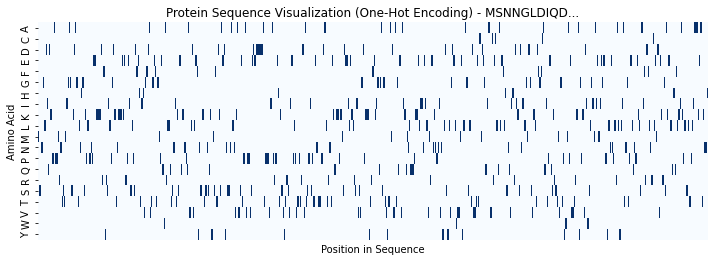

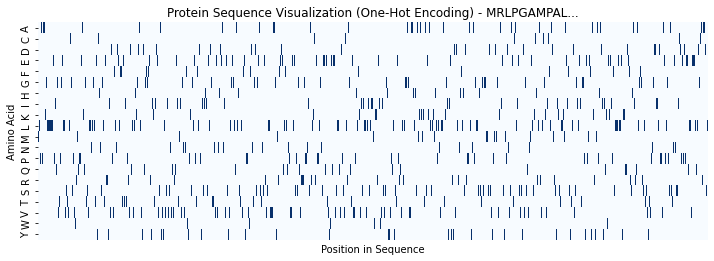

In [13]:
# Function to visualize multiple protein sequences as heatmaps
def visualize_protein_sequences(sequences):
    for sequence in sequences:
        encoded = one_hot_encode(sequence)
        plt.figure(figsize=(12, 4))
        sns.heatmap(encoded.T, cmap='Blues', cbar=False, xticklabels=False, yticklabels=amino_acids)
        plt.title(f'Protein Sequence Visualization (One-Hot Encoding) - {sequence[:10]}...')  # Showing first 10 characters
        plt.xlabel('Position in Sequence')
        plt.ylabel('Amino Acid')
        plt.show()

# Example: Visualizing the first 3 protein sequences from top_20_df
visualize_protein_sequences(top_20_df['FASTA'].head(3))

In [15]:
def one_hot_encode(sequence):
    # Create an empty array of size (len(sequence), 20) for the 20 amino acids
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"  # 20 amino acids
    encoding = np.zeros((len(sequence), 20))  # Initialize a 2D array of zeros
    
    for i, amino_acid in enumerate(sequence):
        if amino_acid in amino_acids:
            encoding[i, amino_acids.index(amino_acid)] = 1
    return encoding

# Test the one-hot encoding on a sequence
test_sequence = "MDRSKENCISGPVKAT"  # Example protein sequence
encoded_test = one_hot_encode(test_sequence)
print(f"Encoded sequence shape: {encoded_test.shape}")
print(f"Encoded sequence:\n{encoded_test}")

Encoded sequence shape: (16, 20)
Encoded sequence:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0.